# PatrolIQ - Exploratory Data Analysis
## Notebook 2: Comprehensive Crime Pattern Analysis

**Objective:**
- Analyze crime distribution across different categories
- Study temporal patterns (hourly, daily, monthly)
- Investigate geographic patterns
- Examine arrest rates and trends

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configure display options
%matplotlib inline
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Load Processed Dataset

In [2]:
# Load processed data
PROCESSED_DATA_PATH = '../data/processed/chicago_crimes_processed.csv'

print("Loading processed dataset...")
df = pd.read_csv(PROCESSED_DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

Loading processed dataset...
Dataset loaded successfully!
Shape: (498569, 34)
Memory usage: 503.03 MB


In [3]:
# Dataset overview
df.head(10)

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location,Crime_Year,Month,Day,Hour,Day_of_Week,Day_Name,Month_Name,Is_Weekend,Is_Late_Night,Is_Rush_Hour,Season,Time_of_Day
0,14111454,JK150303,2026-02-14,090XX S HOUSTON AVE,051A,ASSAULT,AGGRAVATED - HANDGUN,SIDEWALK,0,1,424,4,10,46,04A,1198093.0,1845627.0,2026,02/21/2026 03:41:25 PM,41.731236,-87.549895,"(41.731236433, -87.549895062)",2026,2,14,0,5,Saturday,February,1,1,0,Winter,Night
1,14111080,JK149857,2026-02-14,048XX N FRANCISCO AVE,0460,BATTERY,SIMPLE,RESIDENCE,1,0,2031,20,40,4,08B,1156348.0,1932071.0,2026,02/21/2026 03:41:25 PM,41.969389,-87.700489,"(41.96938944, -87.700488807)",2026,2,14,0,5,Saturday,February,1,1,0,Winter,Night
2,14110206,JK148883,2026-02-14,063XX S RACINE AVE,5002,OTHER OFFENSE,OTHER VEHICLE OFFENSE,STREET,0,0,724,7,16,67,26,1169405.0,1862845.0,2026,02/21/2026 03:41:25 PM,41.779153,-87.654491,"(41.779153403, -87.65449147)",2026,2,14,0,5,Saturday,February,1,1,0,Winter,Night
3,14111117,JK149856,2026-02-14,002XX W 23RD ST,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,APARTMENT,0,0,914,9,11,34,11,1174896.0,1889055.0,2026,02/21/2026 03:41:25 PM,41.850955,-87.633579,"(41.850955345, -87.633578542)",2026,2,14,0,5,Saturday,February,1,1,0,Winter,Night
4,14110668,JK149416,2026-02-14,047XX S KARLOV AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,0,0,815,8,14,57,14,1149825.0,1872931.0,2026,02/21/2026 03:41:25 PM,41.807233,-87.726013,"(41.807232664, -87.726013144)",2026,2,14,0,5,Saturday,February,1,1,0,Winter,Night
5,14114901,JK153670,2026-02-14,054XX S INGLESIDE AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE - PORCH / HALLWAY,0,0,233,2,5,41,14,1183457.0,1869424.0,2026,02/21/2026 03:41:25 PM,41.796891,-87.602771,"(41.796890794, -87.602770958)",2026,2,14,0,5,Saturday,February,1,1,0,Winter,Night
6,14112288,JK151320,2026-02-14,083XX S INGLESIDE AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,0,0,632,6,8,44,14,1184007.0,1849842.0,2026,02/21/2026 03:41:25 PM,41.743143,-87.601365,"(41.743143101, -87.601365206)",2026,2,14,0,5,Saturday,February,1,1,0,Winter,Night
7,14113878,JK152833,2026-02-14,003XX W HUBBARD ST,0870,THEFT,POCKET-PICKING,BAR OR TAVERN,0,0,1831,18,42,8,06,1173688.0,1903250.0,2026,02/21/2026 03:41:25 PM,41.889934,-87.637590,"(41.889934315, -87.637589849)",2026,2,14,0,5,Saturday,February,1,1,0,Winter,Night
8,14110631,JK149329,2026-02-14,026XX E 77TH ST,2820,OTHER OFFENSE,TELEPHONE THREAT,APARTMENT,0,1,421,4,7,43,08A,1195453.0,1854427.0,2026,02/21/2026 03:41:25 PM,41.755450,-87.559276,"(41.755449875, -87.559276166)",2026,2,14,0,5,Saturday,February,1,1,0,Winter,Night
9,14110481,JK149165,2026-02-14,088XX S PARNELL AVE,0910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,0,0,2223,22,21,71,07,1174180.0,1846363.0,2026,02/21/2026 03:41:25 PM,41.733820,-87.637475,"(41.733820008, -87.637474656)",2026,2,14,0,5,Saturday,February,1,1,0,Winter,Night


In [4]:
# Basic statistics
df.describe()

,ID,Date,Arrest,Domestic,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude,Crime_Year,Month,Day,Hour,Day_of_Week,Is_Weekend,Is_Late_Night,Is_Rush_Hour
count,4.985690e+05,498569,498569.000000,498569.000000,498569.000000,498569.000000,498569.000000,498569.000000,4.985690e+05,4.985690e+05,498569.000000,498569.000000,498569.000000,498569.000000,498569.000000,498569.000000,498569.000000,498569.000000,498569.000000,498569.000000,498569.000000
mean,1.370336e+07,2025-01-25 09:36:06.925219584,0.148812,0.187402,1149.820645,11.268180,23.111317,36.280461,1.165493e+06,1.887414e+06,2024.568970,41.846641,-87.668176,2024.568970,6.507400,15.523841,12.498236,3.014836,0.287411,0.260060,0.262182
min,2.796300e+04,2024-01-31 09:48:00,0.000000,0.000000,111.000000,1.000000,0.000000,0.000000,1.092647e+06,1.813897e+06,2024.000000,41.644590,-87.934567,2024.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.354299e+07,2024-07-23 20:57:00,0.000000,0.000000,532.000000,5.000000,10.000000,22.000000,1.154202e+06,1.860362e+06,2024.000000,41.772296,-87.709271,2024.000000,4.000000,8.000000,8.000000,1.000000,0.000000,0.000000,0.000000
50%,1.372878e+07,2025-01-18 18:00:00,0.000000,0.000000,1033.000000,10.000000,23.000000,32.000000,1.167397e+06,1.894001e+06,2025.000000,41.864823,-87.660848,2025.000000,7.000000,15.000000,13.000000,3.000000,0.000000,0.000000,0.000000
75%,1.391919e+07,2025-07-27 17:15:00,0.000000,0.000000,1732.000000,17.000000,34.000000,53.000000,1.176778e+06,1.910199e+06,2025.000000,41.909483,-87.626861,2025.000000,9.000000,23.000000,18.000000,5.000000,1.000000,1.000000,1.000000
max,1.411608e+07,2026-02-14 00:00:00,1.000000,1.000000,2535.000000,31.000000,50.000000,77.000000,1.205119e+06,1.951517e+06,2026.000000,42.022559,-87.524529,2026.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000
std,6.584067e+05,NaN,0.355903,0.390235,708.591084,7.080784,13.938042,21.559980,1.620509e+04,3.146251e+04,0.583194,0.086518,0.059008,0.583194,3.352288,8.866652,6.828375,1.998503,0.452555,0.438668,0.439822


## Step 2: Crime Type Distribution Analysis

In [5]:
# Count crimes by type
crime_counts = df['Primary Type'].value_counts()

print("=== Crime Type Distribution ===")
print(f"Total unique crime types: {df['Primary Type'].nunique()}")
print(f"\nTop 15 Most Common Crimes:")
print(crime_counts.head(15))

# Calculate percentages
crime_percentages = (crime_counts / len(df) * 100).head(15)
print(f"\nPercentages:")
for crime, pct in crime_percentages.items():
    print(f"{crime}: {pct:.2f}%")

=== Crime Type Distribution ===
Total unique crime types: 31

Top 15 Most Common Crimes:
Primary Type
THEFT                         116195
BATTERY                        89549
CRIMINAL DAMAGE                55126
ASSAULT                        45346
MOTOR VEHICLE THEFT            39076
OTHER OFFENSE                  33997
DECEPTIVE PRACTICE             30631
BURGLARY                       18609
ROBBERY                        14720
NARCOTICS                      13686
WEAPONS VIOLATION              13173
CRIMINAL TRESPASS              10521
CRIMINAL SEXUAL ASSAULT         3311
OFFENSE INVOLVING CHILDREN      3205
SEX OFFENSE                     2564
Name: count, dtype: int64

Percentages:
THEFT: 23.31%
BATTERY: 17.96%
CRIMINAL DAMAGE: 11.06%
ASSAULT: 9.10%
MOTOR VEHICLE THEFT: 7.84%
OTHER OFFENSE: 6.82%
DECEPTIVE PRACTICE: 6.14%
BURGLARY: 3.73%
ROBBERY: 2.95%
NARCOTICS: 2.75%
WEAPONS VIOLATION: 2.64%
CRIMINAL TRESPASS: 2.11%
CRIMINAL SEXUAL ASSAULT: 0.66%
OFFENSE INVOLVING CHILDREN: 0.6

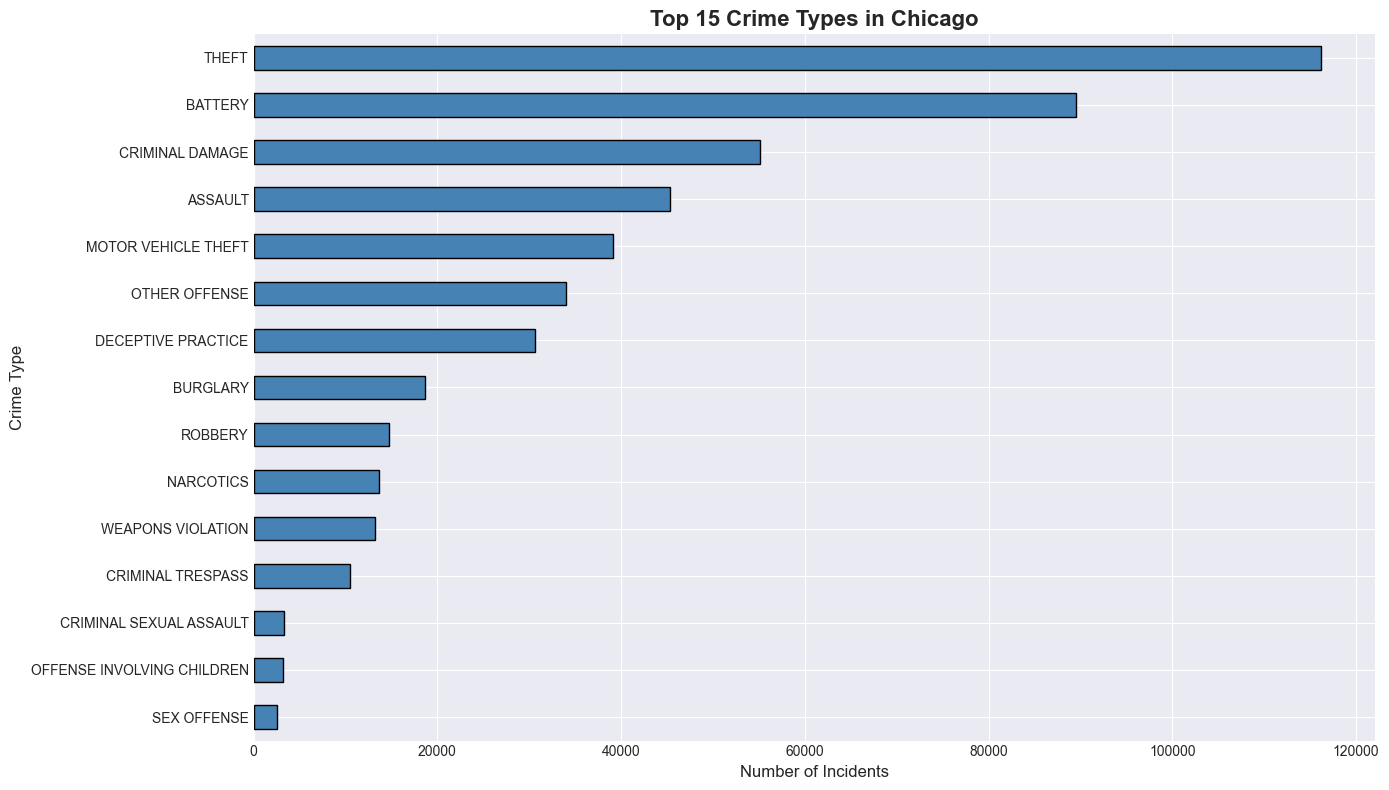

In [6]:
# Visualize top 15 crime types
plt.figure(figsize=(14, 8))
crime_counts.head(15).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Crime Types in Chicago', fontsize=16, fontweight='bold')
plt.xlabel('Number of Incidents', fontsize=12)
plt.ylabel('Crime Type', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

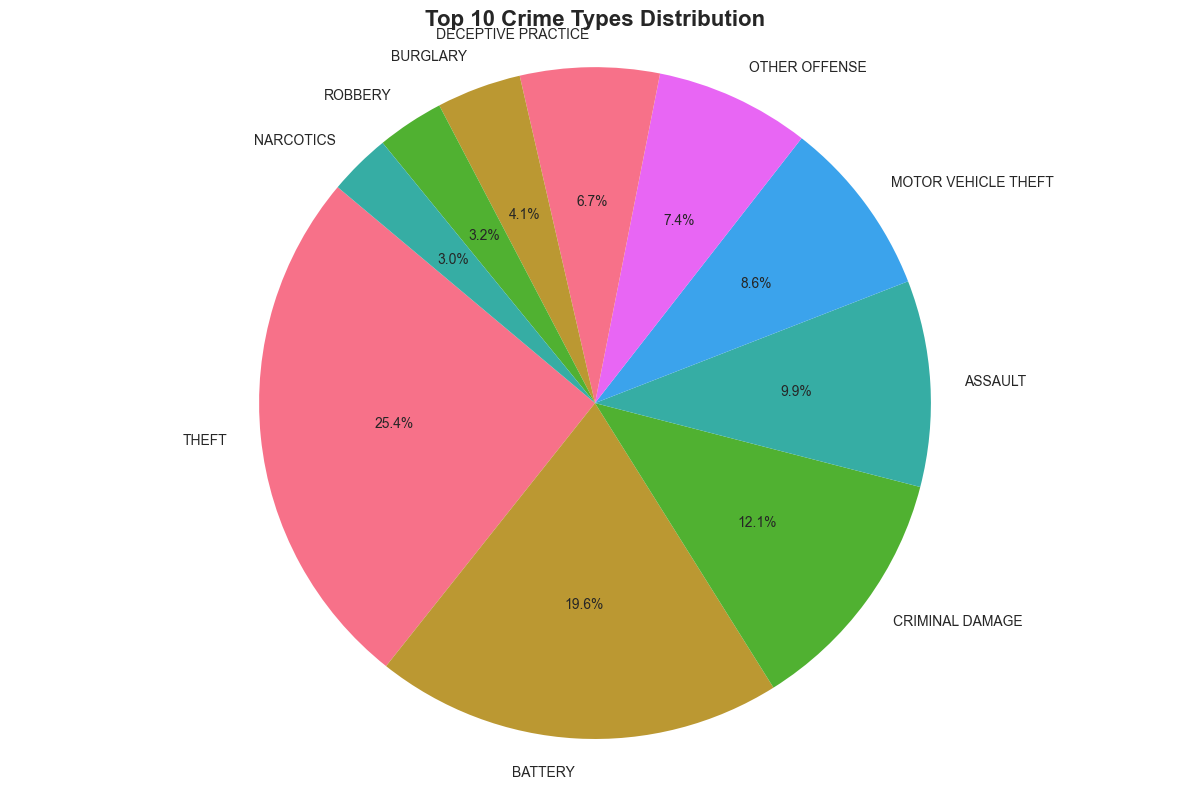

In [7]:
# Pie chart for top 10 crimes
plt.figure(figsize=(12, 8))
top_crimes = crime_counts.head(10)
plt.pie(top_crimes, labels=top_crimes.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Crime Types Distribution', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

## Step 3: Temporal Analysis - Hourly Patterns

In [8]:
# Crimes by hour of day
hourly_crimes = df['Hour'].value_counts().sort_index()

print("=== Hourly Crime Distribution ===")
print(hourly_crimes)

# Identify peak hours
peak_hour = hourly_crimes.idxmax()
min_hour = hourly_crimes.idxmin()
print(f"\nPeak crime hour: {peak_hour}:00 ({hourly_crimes[peak_hour]:,} crimes)")
print(f"Lowest crime hour: {min_hour}:00 ({hourly_crimes[min_hour]:,} crimes)")

=== Hourly Crime Distribution ===
Hour
0     33776
1     16500
2     14721
3     12901
4     10564
5      9178
6      9797
7     12795
8     17289
9     20577
10    21456
11    22024
12    28640
13    22714
14    24084
15    27119
16    26794
17    26858
18    26403
19    25930
20    24611
21    22642
22    21581
23    19615
Name: count, dtype: int64

Peak crime hour: 0:00 (33,776 crimes)
Lowest crime hour: 5:00 (9,178 crimes)


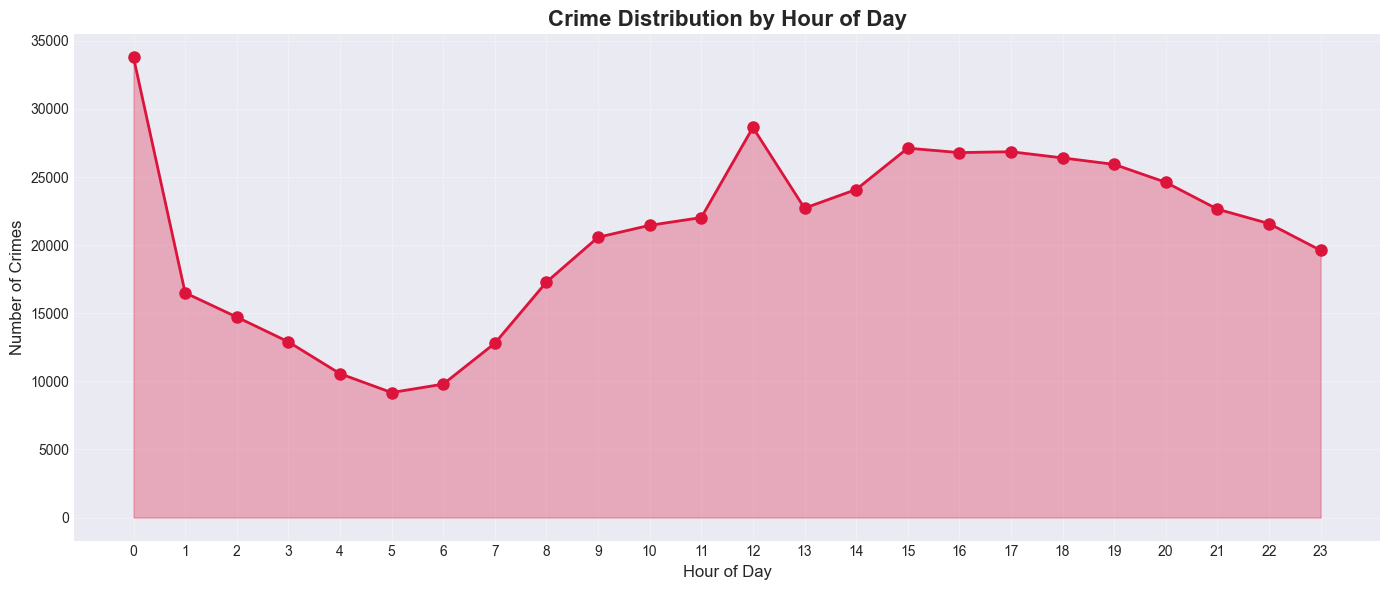

In [9]:
# Visualize hourly pattern
plt.figure(figsize=(14, 6))
plt.plot(hourly_crimes.index, hourly_crimes.values, marker='o', linewidth=2, 
         markersize=8, color='crimson')
plt.fill_between(hourly_crimes.index, hourly_crimes.values, alpha=0.3, color='crimson')
plt.title('Crime Distribution by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4: Temporal Analysis - Daily Patterns

In [10]:
# Crimes by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_crimes = df['Day_Name'].value_counts().reindex(day_order)

print("=== Daily Crime Distribution ===")
print(daily_crimes)

# Weekend vs Weekday
weekend_crimes = df[df['Is_Weekend'] == 1].shape[0]
weekday_crimes = df[df['Is_Weekend'] == 0].shape[0]

print(f"\nWeekday crimes: {weekday_crimes:,} ({weekday_crimes/len(df)*100:.2f}%)")
print(f"Weekend crimes: {weekend_crimes:,} ({weekend_crimes/len(df)*100:.2f}%)")

=== Daily Crime Distribution ===
Day_Name
Monday       71468
Tuesday      69216
Wednesday    70716
Thursday     70281
Friday       73594
Saturday     72527
Sunday       70767
Name: count, dtype: int64

Weekday crimes: 355,275 (71.26%)
Weekend crimes: 143,294 (28.74%)


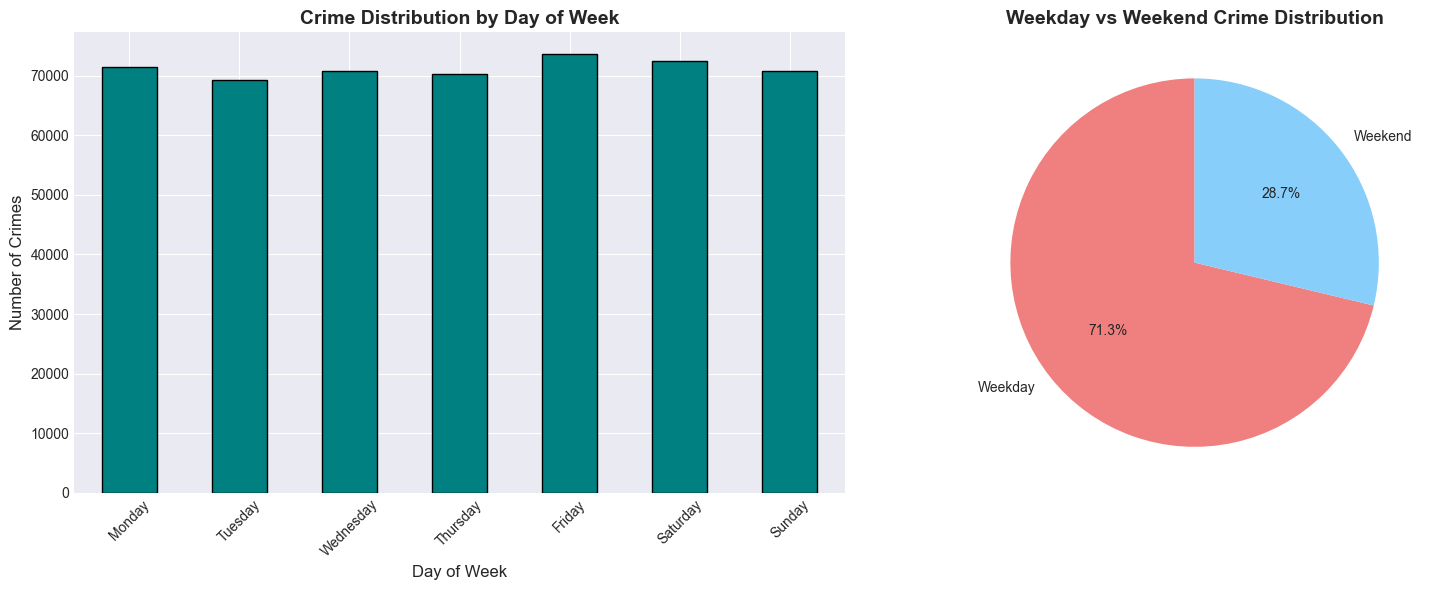

In [11]:
# Visualize daily pattern
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart by day
daily_crimes.plot(kind='bar', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Crime Distribution by Day of Week', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day of Week', fontsize=12)
axes[0].set_ylabel('Number of Crimes', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Weekend vs Weekday pie chart
axes[1].pie([weekday_crimes, weekend_crimes], 
            labels=['Weekday', 'Weekend'],
            autopct='%1.1f%%', 
            colors=['lightcoral', 'lightskyblue'],
            startangle=90)
axes[1].set_title('Weekday vs Weekend Crime Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 5: Temporal Analysis - Monthly and Seasonal Patterns

In [12]:
# Crimes by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_crimes = df['Month_Name'].value_counts().reindex(month_order)

print("=== Monthly Crime Distribution ===")
print(monthly_crimes)

# Seasonal analysis
seasonal_crimes = df['Season'].value_counts()
print("\n=== Seasonal Crime Distribution ===")
print(seasonal_crimes)

=== Monthly Crime Distribution ===
Month_Name
January      35460
February     43532
March        40585
April        39957
May          42661
June         44211
July         46652
August       44206
September    43188
October      43308
November     37982
December     36827
Name: count, dtype: int64

=== Seasonal Crime Distribution ===
Season
Summer    135069
Fall      124478
Spring    123203
Winter    115819
Name: count, dtype: int64


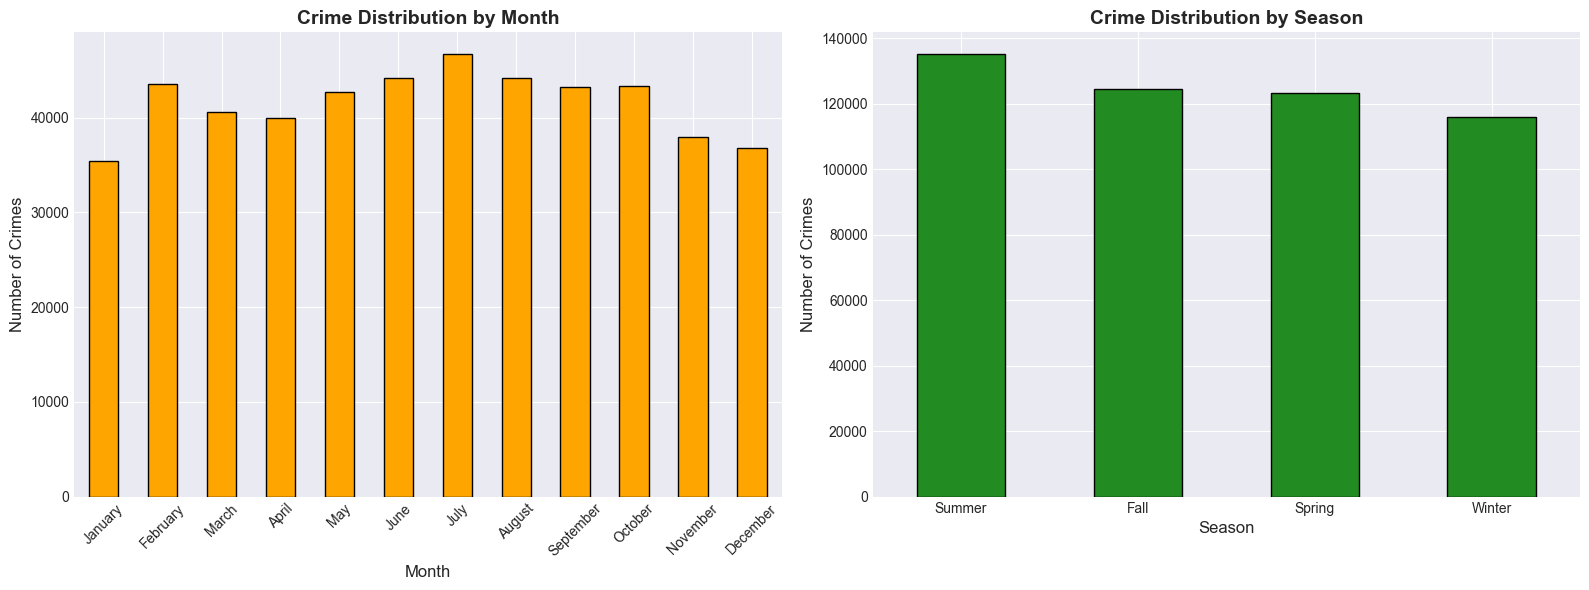

In [13]:
# Visualize monthly and seasonal patterns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Monthly crimes
monthly_crimes.plot(kind='bar', ax=axes[0], color='orange', edgecolor='black')
axes[0].set_title('Crime Distribution by Month', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Number of Crimes', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Seasonal crimes
seasonal_crimes.plot(kind='bar', ax=axes[1], color='forestgreen', edgecolor='black')
axes[1].set_title('Crime Distribution by Season', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Season', fontsize=12)
axes[1].set_ylabel('Number of Crimes', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Step 6: Arrest Rate Analysis

In [14]:
# Overall arrest statistics
arrest_rate = df['Arrest'].sum() / len(df) * 100
arrests_made = df['Arrest'].sum()
no_arrests = len(df) - arrests_made

print("=== Arrest Statistics ===")
print(f"Total crimes with arrest: {arrests_made:,} ({arrest_rate:.2f}%)")
print(f"Total crimes without arrest: {no_arrests:,} ({100-arrest_rate:.2f}%)")

# Arrest rate by crime type
arrest_by_crime = df.groupby('Primary Type')['Arrest'].agg(['sum', 'count'])
arrest_by_crime['arrest_rate'] = (arrest_by_crime['sum'] / arrest_by_crime['count'] * 100)
arrest_by_crime = arrest_by_crime.sort_values('arrest_rate', ascending=False)

print("\n=== Top 10 Crime Types by Arrest Rate ===")
print(arrest_by_crime.head(10))

=== Arrest Statistics ===
Total crimes with arrest: 74,193 (14.88%)
Total crimes without arrest: 424,376 (85.12%)

=== Top 10 Crime Types by Arrest Rate ===
                                     sum  count  arrest_rate
Primary Type                                                
CONCEALED CARRY LICENSE VIOLATION    464    475    97.684211
GAMBLING                              34     35    97.142857
PUBLIC INDECENCY                      24     25    96.000000
NARCOTICS                          13043  13686    95.301768
LIQUOR LAW VIOLATION                 385    407    94.594595
PROSTITUTION                         467    497    93.963783
INTERFERENCE WITH PUBLIC OFFICER    1511   1675    90.208955
WEAPONS VIOLATION                   8999  13173    68.313976
NON-CRIMINAL                           4      6    66.666667
OTHER NARCOTIC VIOLATION               8     15    53.333333


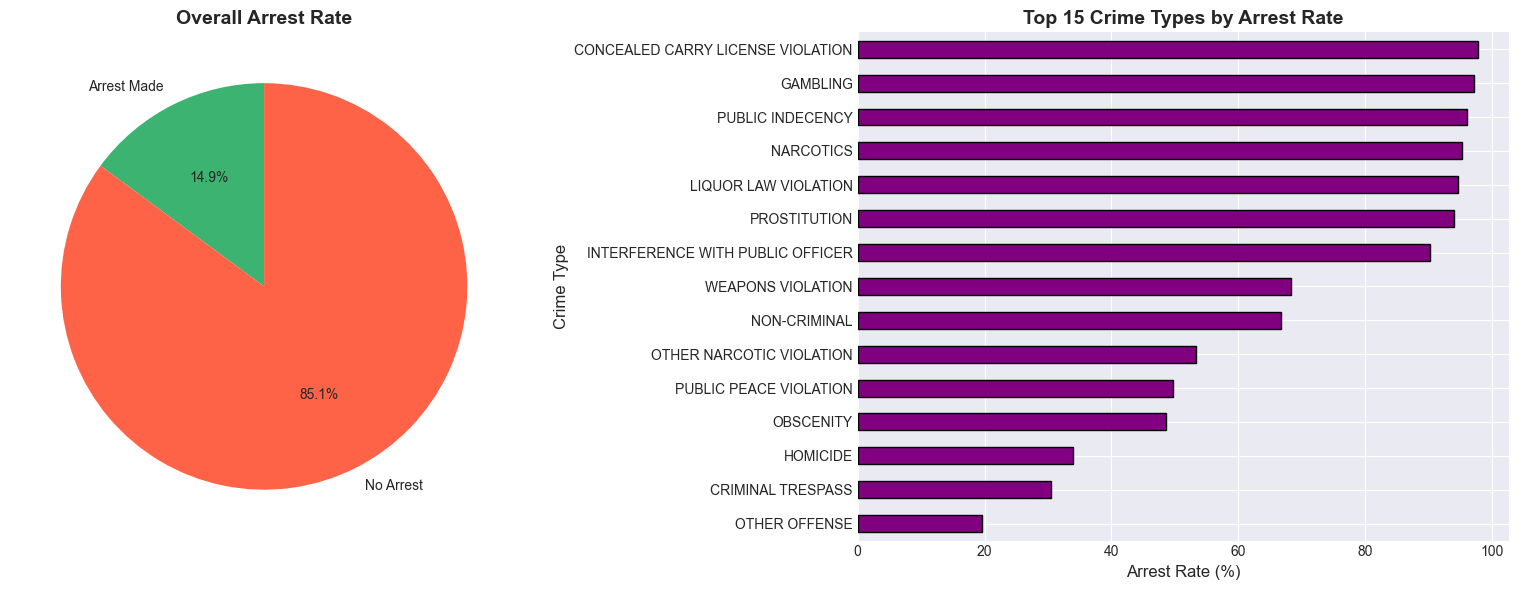

In [15]:
# Visualize arrest rates
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall arrest pie chart
axes[0].pie([arrests_made, no_arrests], 
            labels=['Arrest Made', 'No Arrest'],
            autopct='%1.1f%%', 
            colors=['mediumseagreen', 'tomato'],
            startangle=90)
axes[0].set_title('Overall Arrest Rate', fontsize=14, fontweight='bold')

# Top crime types by arrest rate
top_arrest_rates = arrest_by_crime.head(15)['arrest_rate']
top_arrest_rates.plot(kind='barh', ax=axes[1], color='purple', edgecolor='black')
axes[1].set_title('Top 15 Crime Types by Arrest Rate', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Arrest Rate (%)', fontsize=12)
axes[1].set_ylabel('Crime Type', fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Step 7: Geographic Distribution Analysis

In [16]:
# District-wise crime analysis
district_crimes = df[df['District'] > 0]['District'].value_counts().sort_index()

print("=== District-wise Crime Distribution ===")
print(f"Total districts: {len(district_crimes)}")
print(f"\nTop 10 Districts by Crime Count:")
print(district_crimes.sort_values(ascending=False).head(10))

=== District-wise Crime Distribution ===
Total districts: 23

Top 10 Districts by Crime Count:
District
8     32658
12    31406
1     28831
6     28615
4     26927
18    26914
19    26728
11    26708
2     26221
3     26103
Name: count, dtype: int64


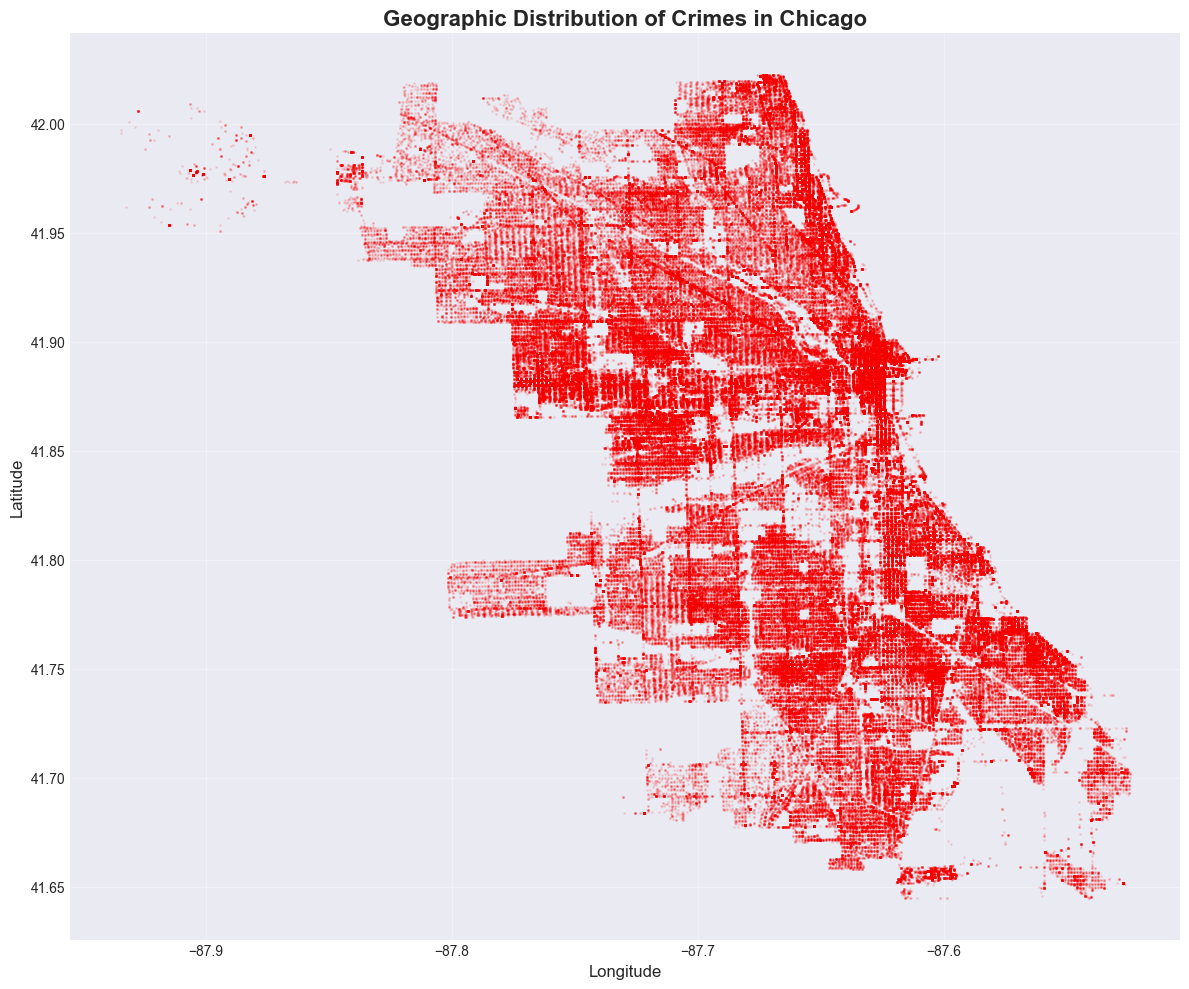

In [17]:
# Scatter plot of crime locations
plt.figure(figsize=(12, 10))
plt.scatter(df['Longitude'], df['Latitude'], 
           alpha=0.1, s=1, c='red')
plt.title('Geographic Distribution of Crimes in Chicago', fontsize=16, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

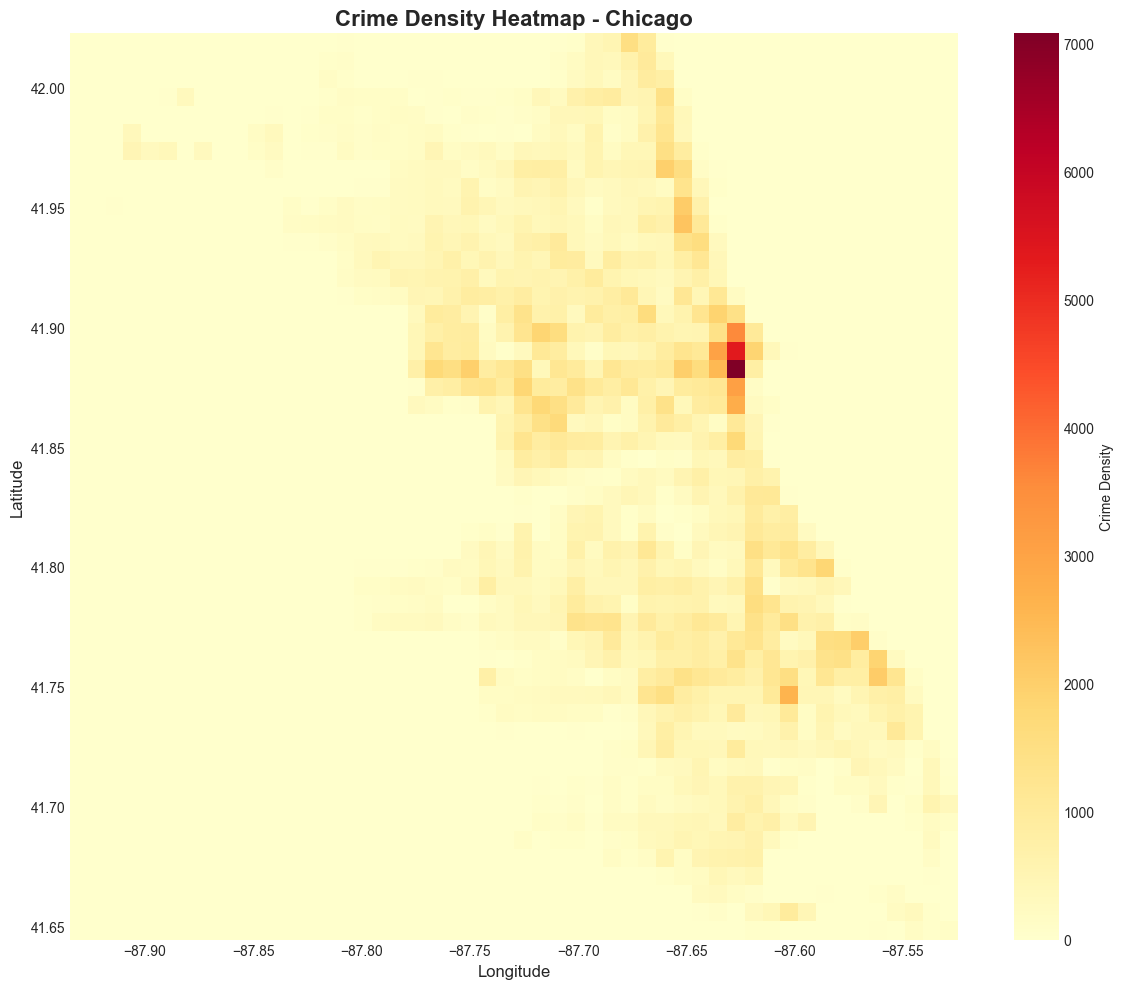

In [18]:
# 2D Histogram (Heatmap) of crime locations
plt.figure(figsize=(12, 10))
plt.hist2d(df['Longitude'], df['Latitude'], bins=50, cmap='YlOrRd')
plt.colorbar(label='Crime Density')
plt.title('Crime Density Heatmap - Chicago', fontsize=16, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.tight_layout()
plt.show()

## Step 8: Correlation Analysis

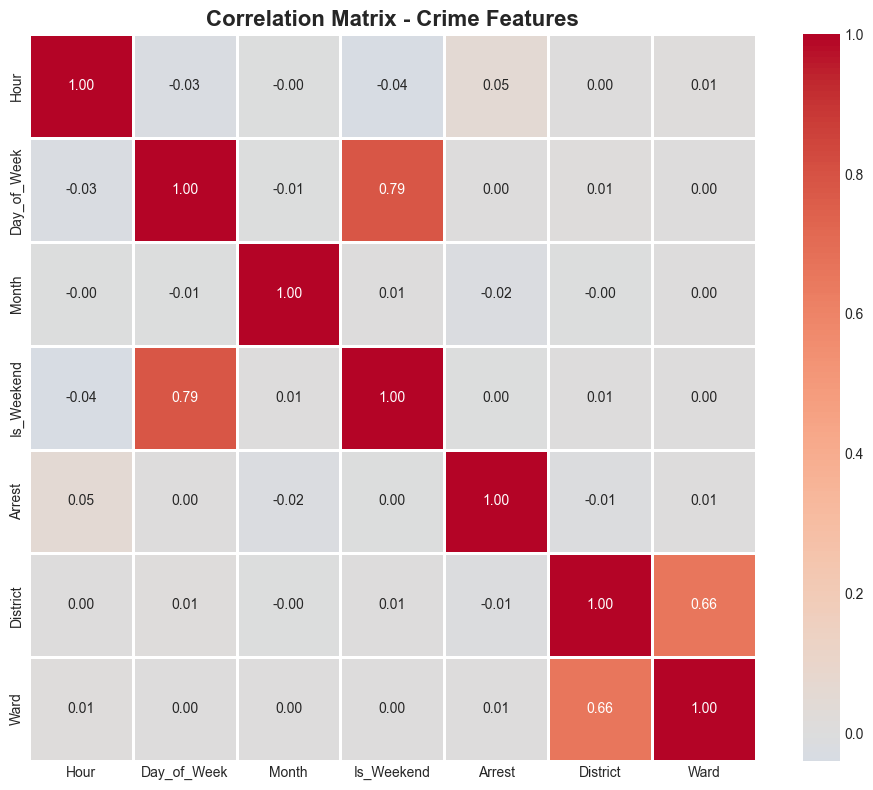

In [19]:
# Select numeric columns for correlation
numeric_cols = ['Hour', 'Day_of_Week', 'Month', 'Is_Weekend', 'Arrest', 'District', 'Ward']
correlation_matrix = df[numeric_cols].corr()

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix - Crime Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 9: Advanced Pattern Analysis

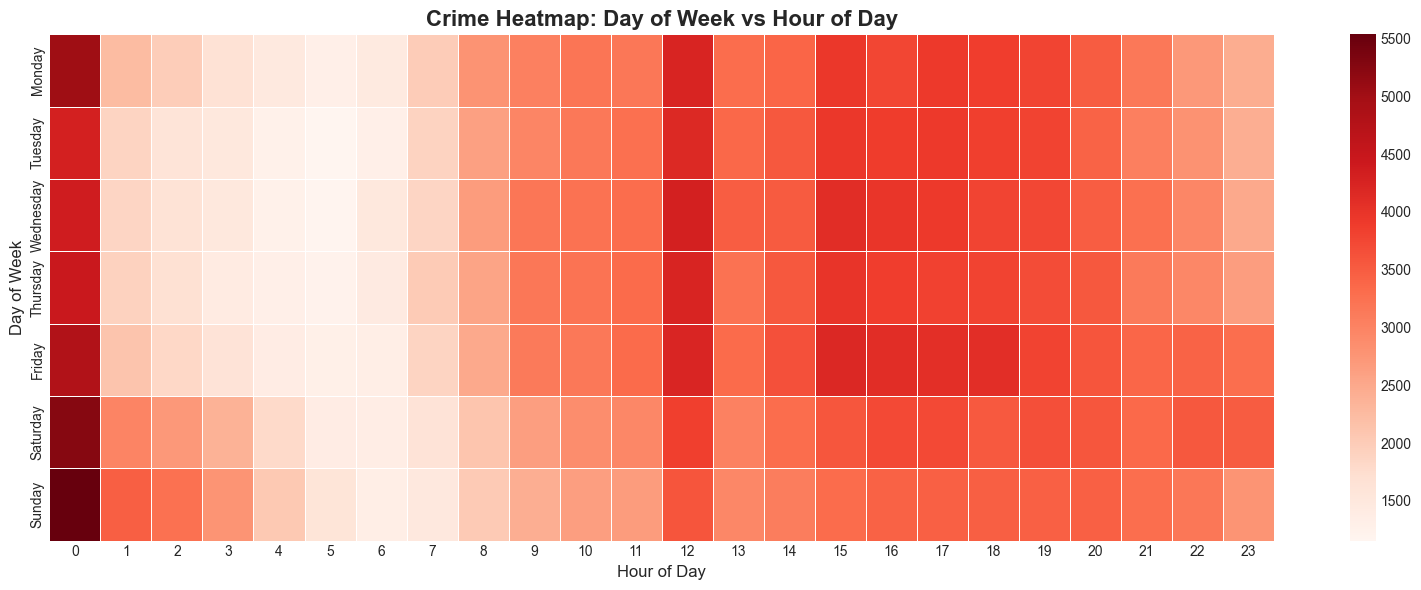

In [20]:
# Hourly crime pattern by day of week (Heatmap)
hourly_daily = df.groupby(['Day_Name', 'Hour']).size().reset_index(name='Count')
hourly_daily_pivot = hourly_daily.pivot(index='Day_Name', columns='Hour', values='Count')
hourly_daily_pivot = hourly_daily_pivot.reindex(day_order)

plt.figure(figsize=(16, 6))
sns.heatmap(hourly_daily_pivot, cmap='Reds', annot=False, fmt='d', linewidths=0.5)
plt.title('Crime Heatmap: Day of Week vs Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
# Top crime types by season
season_crime = df.groupby(['Season', 'Primary Type']).size().reset_index(name='Count')
top_crimes_per_season = season_crime.sort_values('Count', ascending=False).groupby('Season').head(5)

print("=== Top 5 Crime Types per Season ===")
for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    print(f"\n{season}:")
    season_data = top_crimes_per_season[top_crimes_per_season['Season'] == season]
    print(season_data[['Primary Type', 'Count']].to_string(index=False))

=== Top 5 Crime Types per Season ===

Winter:
       Primary Type  Count
              THEFT  26647
            BATTERY  20225
    CRIMINAL DAMAGE  12242
            ASSAULT   9938
MOTOR VEHICLE THEFT   9269

Spring:
       Primary Type  Count
              THEFT  27873
            BATTERY  22642
    CRIMINAL DAMAGE  13596
            ASSAULT  11705
MOTOR VEHICLE THEFT   9332

Summer:
       Primary Type  Count
              THEFT  32577
            BATTERY  24320
    CRIMINAL DAMAGE  15181
            ASSAULT  12233
MOTOR VEHICLE THEFT  10761

Fall:
       Primary Type  Count
              THEFT  29098
            BATTERY  22362
    CRIMINAL DAMAGE  14107
            ASSAULT  11470
MOTOR VEHICLE THEFT   9714


## Step 10: Key Insights Summary

In [22]:
print("="*80)
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("="*80)

print(f"\n1. DATASET OVERVIEW")
print(f"   - Total crime records analyzed: {len(df):,}")
print(f"   - Unique crime types: {df['Primary Type'].nunique()}")
print(f"   - Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

print(f"\n2. MOST COMMON CRIMES")
top_3_crimes = df['Primary Type'].value_counts().head(3)
for i, (crime, count) in enumerate(top_3_crimes.items(), 1):
    print(f"   {i}. {crime}: {count:,} incidents ({count/len(df)*100:.1f}%)")

print(f"\n3. TEMPORAL PATTERNS")
print(f"   - Peak crime hour: {hourly_crimes.idxmax()}:00")
print(f"   - Lowest crime hour: {hourly_crimes.idxmin()}:00")
print(f"   - Highest crime day: {daily_crimes.idxmax()}")
print(f"   - Weekend crime rate: {weekend_crimes/len(df)*100:.1f}%")

print(f"\n4. ARREST STATISTICS")
print(f"   - Overall arrest rate: {arrest_rate:.2f}%")
print(f"   - Crimes with highest arrest rate: {arrest_by_crime.index[0]}")

print(f"\n5. GEOGRAPHIC INSIGHTS")
print(f"   - Districts analyzed: {len(district_crimes)}")
print(f"   - District with most crimes: District {district_crimes.idxmax()}")

print("\n" + "="*80)
print("✅ EXPLORATORY DATA ANALYSIS COMPLETE!")
print("="*80)

KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1. DATASET OVERVIEW
   - Total crime records analyzed: 498,569
   - Unique crime types: 31
   - Date range: 2024-01-31 to 2026-02-14

2. MOST COMMON CRIMES
   1. THEFT: 116,195 incidents (23.3%)
   2. BATTERY: 89,549 incidents (18.0%)
   3. CRIMINAL DAMAGE: 55,126 incidents (11.1%)

3. TEMPORAL PATTERNS
   - Peak crime hour: 0:00
   - Lowest crime hour: 5:00
   - Highest crime day: Friday
   - Weekend crime rate: 28.7%

4. ARREST STATISTICS
   - Overall arrest rate: 14.88%
   - Crimes with highest arrest rate: CONCEALED CARRY LICENSE VIOLATION

5. GEOGRAPHIC INSIGHTS
   - Districts analyzed: 23
   - District with most crimes: District 8

✅ EXPLORATORY DATA ANALYSIS COMPLETE!


## ✅ EDA Complete!

**Key Findings:**
- Identified top crime types and their distribution
- Discovered temporal patterns (hourly, daily, seasonal)
- Analyzed arrest rates across crime types
- Visualized geographic crime distribution
- Uncovered correlations between features

**Next Step:** Proceed to `03_feature_engineering.ipynb`